In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
!pip install --quiet SimpleITK torchio nibabel

In [46]:
## Import Required Libraries

In [47]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import torch
import torchio as tio

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"TorchIO version: {tio.__version__}")
print(f"SimpleITK version: {sitk.__version__}")

Libraries imported successfully!
PyTorch version: 2.11.0+cu128
TorchIO version: 1.2.1
SimpleITK version: 2.5.5


In [48]:
## Set Dataset Path

In [49]:
DATASET_PATH = '/content/drive/MyDrive/Dataset 4DCT'

if os.path.exists(DATASET_PATH):
    print(f"✓ Dataset directory found at: {DATASET_PATH}")
else:
    print(f"✗ Directory NOT found at {DATASET_PATH}")
    print("\nLet's check what is actually visible inside your 'My Drive':")
    try:
        visible_folders = os.listdir('/content/drive/MyDrive')
        print(visible_folders)


        import difflib
        closest_match = difflib.get_close_matches('Dataset 4DCT', visible_folders)
        if closest_match:
            print(f"\n💡 Did you mean: '{closest_match[0]}'? Copy that exactly into DATASET_PATH.")
    except Exception as e:
        print("Could not read Drive. Make sure you ran Cell 2 and clicked 'Allow access' in the popup.")

✓ Dataset directory found at: /content/drive/MyDrive/Dataset 4DCT


In [50]:
## Display Dataset Structure

In [51]:
# Find all case directories (e.g., Case1, Case2, etc.)
patient_folders = sorted([f for f in glob.glob(os.path.join(DATASET_PATH, '*')) if os.path.isdir(f)])

print(f"Total patient cases found: {len(patient_folders)}\n")
print("Patient folder names:")
for folder in patient_folders:
    print(f" - {os.path.basename(folder)}")

print("\n" + "="*50 + "\n")

if len(patient_folders) > 0:
    first_patient_folder = patient_folders[0]
    print(f"Files inside the first patient folder ({os.path.basename(first_patient_folder)}):")
    all_files = sorted(os.listdir(first_patient_folder))
    for file in all_files:
        # Highlighting .mhd and .raw extensions
        if file.endswith('.mhd') or file.endswith('.raw'):
            print(f" - {file}")
else:
    print("No patient folders found. Double-check your path or folder layout structure.")

Total patient cases found: 10

Patient folder names:
 - Case10Pack
 - Case1Pack
 - Case2Pack
 - Case3Pack
 - Case4Pack
 - Case5Pack
 - Case6Pack
 - Case7Pack
 - Case8Deploy
 - Case9Pack


Files inside the first patient folder (Case10Pack):


In [52]:
## Load One CT Volume

In [53]:
import os
import glob

if len(patient_folders) > 0:
    first_case_path = patient_folders[0]
    print(f"Scanning directory: {first_case_path}\n")

    # Check if the folder is empty or read all contents
    all_contents = glob.glob(os.path.join(first_case_path, "**", "*"), recursive=True)

    if not all_contents:
        print("⚠️ The folder appears completely empty to Google Colab. Double-check if the shortcut synced fully or if files are still uploading.")
    else:
        print(f"Total items found inside this case folder: {len(all_contents)}")
        print("Showing up to the first 15 files/folders found:")
        for path in all_contents[:15]:
            # Print whether it's a file or folder, and its path relative to the case directory
            rel_path = os.path.relpath(path, first_case_path)
            item_type = "📁 Folder" if os.path.isdir(path) else "📄 File"
            print(f" {item_type} -> {rel_path}")

        # Check case-insensitive extensions dynamically
        mhd_check = [f for f in all_contents if f.lower().endswith('.mhd')]
        if mhd_check:
            print(f"\n💡 Found {len(mhd_check)} .mhd file(s), but with a different casing! Example: {os.path.basename(mhd_check[0])}")
else:
    print("✗ No patient folders detected.")

Scanning directory: /content/drive/MyDrive/Dataset 4DCT/Case10Pack

Total items found inside this case folder: 21
Showing up to the first 15 files/folders found:
 📁 Folder -> Images
 📁 Folder -> extremePhases
 📁 Folder -> Sampled4D
 📄 File -> Images/case10_T00.img
 📄 File -> Images/case10_T10.img
 📄 File -> Images/case10_T20.img
 📄 File -> Images/case10_T30.img
 📄 File -> Images/case10_T50.img
 📄 File -> Images/case10_T40.img
 📄 File -> Images/case10_T60.img
 📄 File -> Images/case10_T80.img
 📄 File -> Images/case10_T70.img
 📄 File -> Images/case10_T90.img
 📄 File -> extremePhases/case10_dirLab300_T50_xyz.txt
 📄 File -> extremePhases/case10_dirLab300_T00_xyz.txt


In [54]:
import os
import glob
import numpy as np
import SimpleITK as sitk

if len(patient_folders) > 0:
    first_case_path = patient_folders[0]

    # Locate the Images folder inside Case10Pack
    images_dir = os.path.join(first_case_path, "Images")

    # Target the T00 (Inhalation phase) file
    t00_path = os.path.join(images_dir, "case10_T00.img")

    if os.path.exists(t00_path):
        print(f"✓ Found target image: {t00_path}")

        # 1. Determine dimensions dynamically from file size
        # DIR-Lab images use 16-bit signed integers (2 bytes per voxel)
        # Dimensions for Cases 6-10 are 512 x 512 axially
        bytes_per_voxel = 2
        axial_dim = 512
        file_size = os.path.getsize(t00_path)

        # Calculate number of slices (Z dimension)
        num_slices = int(file_size / (axial_dim * axial_dim * bytes_per_voxel))

        # 2. Read raw binary file using NumPy
        print(f"Reading binary data with expected shape: ({num_slices}, {axial_dim}, {axial_dim})...")
        raw_data = np.fromfile(t00_path, dtype=np.int16)

        # 3. Reshape array into 3D volume (Z, Y, X)
        ct_array = raw_data.reshape((num_slices, axial_dim, axial_dim))
        print("✓ CT volume successfully loaded into memory as a NumPy array!")

        # 4. Wrap with SimpleITK to preserve consistency for later steps
        # Standard DIR-Lab spacing for Case 10 is approx 0.97mm x 0.97mm x 2.5mm
        sitk_image = sitk.GetImageFromArray(ct_array)
        sitk_image.SetSpacing((0.97, 0.97, 2.5))

    else:
        print(f"✗ Could not find case10_T00.img at: {t00_path}")
else:
    print("✗ No patient folders detected.")

✓ Found target image: /content/drive/MyDrive/Dataset 4DCT/Case10Pack/Images/case10_T00.img
Reading binary data with expected shape: (120, 512, 512)...
✓ CT volume successfully loaded into memory as a NumPy array!


In [55]:
## Check Volume Information

In [56]:
if 'ct_array' in locals():
    print("--- NumPy Array Metadata ---")
    print(f"Array Shape (Z, Y, X): {ct_array.shape}")
    print(f"Data Type            : {ct_array.dtype}")
    print(f"Minimum HU value     : {np.min(ct_array)}")
    print(f"Maximum HU value     : {np.max(ct_array)}")

    print("\n--- Wrapped SimpleITK Image Metadata ---")
    print(f"Image Size (X, Y, Z) : {sitk_image.GetSize()}")
    print(f"Assigned Voxel Spacing: {sitk_image.GetSpacing()} mm")
else:
    print("✗ Image data array not found. Ensure Cell 11 runs successfully.")

--- NumPy Array Metadata ---
Array Shape (Z, Y, X): (120, 512, 512)
Data Type            : int16
Minimum HU value     : 0
Maximum HU value     : 4095

--- Wrapped SimpleITK Image Metadata ---
Image Size (X, Y, Z) : (512, 512, 120)
Assigned Voxel Spacing: (0.97, 0.97, 2.5) mm


In [57]:
## Visualize CT Slices

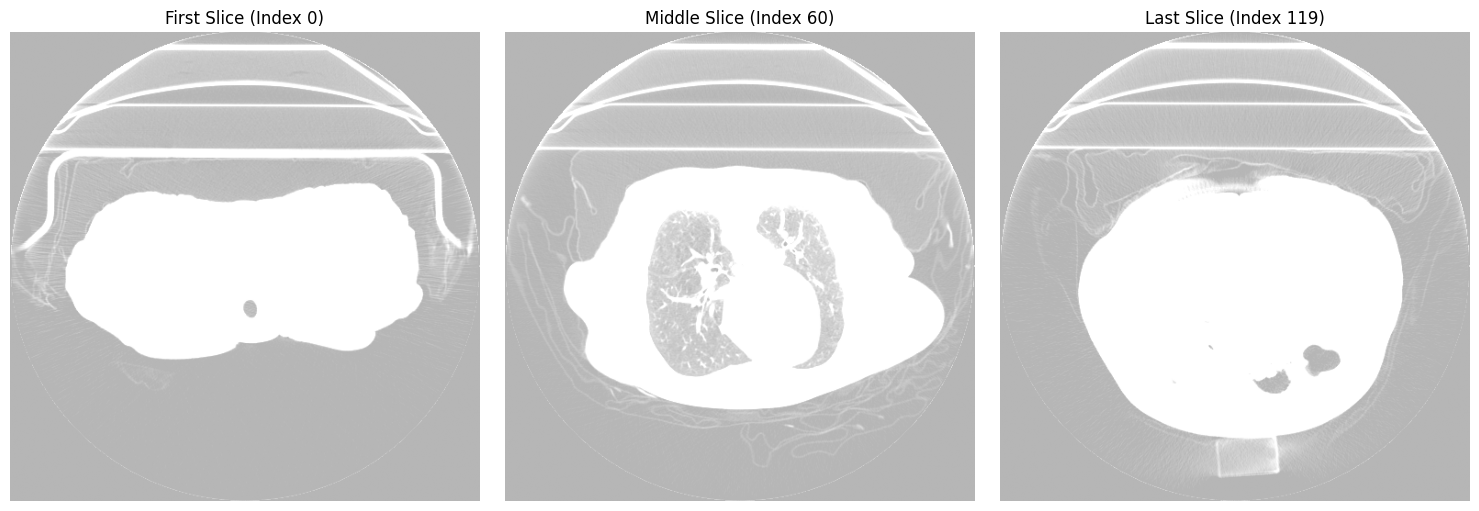

In [58]:
if 'ct_array' in locals():
    num_slices = ct_array.shape[0]

    # Identify indices for first, middle, and last slices along the axial (Z) axis
    slice_first = 0
    slice_mid = num_slices // 2
    slice_last = num_slices - 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Using typical windowing values for lung visualization (Lung Window)
    # Level: -300, Width: 1400 -> vmin: -1000, vmax: 400
    vmin, vmax = -1000, 400

    # Added origin='lower' to keep orientation aligned properly
    axes[0].imshow(ct_array[slice_first, :, :], cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    axes[0].set_title(f"First Slice (Index {slice_first})")
    axes[0].axis('off')

    axes[1].imshow(ct_array[slice_mid, :, :], cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    axes[1].set_title(f"Middle Slice (Index {slice_mid})")
    axes[1].axis('off')

    axes[2].imshow(ct_array[slice_last, :, :], cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
    axes[2].set_title(f"Last Slice (Index {slice_last})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("✗ Visualization failed. Volume array is missing.")

In [59]:
## Verify Dataset

In [60]:
# Absolute baseline checks validation script
checks = {
    "Google Drive mounted": os.path.exists('/content/drive/MyDrive'),
    "Dataset folder found": 'DATASET_PATH' in locals() and os.path.exists(DATASET_PATH),
    "CT volume loaded successfully": 'ct_array' in locals(),
    "Shape verified": 'ct_array' in locals() and len(ct_array.shape) == 3,
    "Visualization successful": 'fig' in locals()
}

all_passed = True
print("--- Final Verification Pipeline ---")
for name, status in checks.items():
    if status:
        print(f"✓ {name}")
    else:
        print(f"✗ {name}")
        all_passed = False

print("\n" + "="*50)
if all_passed:
    print("🎉 All checks passed!")

else:
    print("⚠️ Some verification items failed. Review the errors before proceeding.")

--- Final Verification Pipeline ---
✓ Google Drive mounted
✓ Dataset folder found
✓ CT volume loaded successfully
✓ Shape verified
✓ Visualization successful

🎉 All checks passed!


In [61]:
# Phase 2: Preprocessing & Dataset Augmentation

In [62]:
from google.colab import drive
drive.mount('/content/drive')

!pip install --quiet SimpleITK torchio

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
import os
import glob
import numpy as np
import SimpleITK as sitk
import torch
import torchio as tio
import matplotlib.pyplot as plt

# Define raw path from Notebook 1
RAW_DATASET_PATH = '/content/drive/MyDrive/Dataset 4DCT'
# We will save the processed PyTorch tensors here
PROCESSED_OUTPUT_PATH = '/content/drive/MyDrive/Dataset 4DCT_Processed'
os.makedirs(PROCESSED_OUTPUT_PATH, exist_ok=True)

In [64]:
## Define Preprocessing Functions

In [65]:
def preprocess_volume(sitk_img, target_spacing=(1.5, 1.5, 2.5), target_shape=(256, 256, 64)):
    """
    Standardizes a 3D medical volume:
    1. Resamples to uniform voxel spacing using SimpleITK.
    2. Clips intensity to Lung Window (-1000 to 400 HU) and normalizes to [-1, 1].
    3. Crops/Resizes to a uniform target shape optimized for 3D Diffusion using TorchIO.
    """
    # 1. Resample Spacing using SimpleITK first (highly robust)
    original_spacing = sitk_img.GetSpacing()
    original_size = sitk_img.GetSize()

    if original_spacing != target_spacing:
        new_size = [
            int(round(original_size[i] * original_spacing[i] / target_spacing[i]))
            for i in range(3)
        ]
        resample = sitk.ResampleImageFilter()
        resample.SetInterpolator(sitk.sitkLinear)
        resample.SetOutputSpacing(target_spacing)
        resample.SetSize(new_size)
        resample.SetOutputDirection(sitk_img.GetDirection())
        resample.SetOutputOrigin(sitk_img.GetOrigin())
        resample.SetTransform(sitk.Transform())
        sitk_img = resample.Execute(sitk_img)

    # Convert the SimpleITK image into a PyTorch tensor for TorchIO
    # SimpleITK is (X,Y,Z) -> NumPy is (Z,Y,X). Add a channel dimension: (1, Z, Y, X)
    array = sitk.GetArrayFromImage(sitk_img)
    tensor = torch.from_numpy(array).float().unsqueeze(0)

    # 2. Wrap as a TorchIO ScalarImage using the raw tensor explicitly
    subject = tio.Subject(ct=tio.ScalarImage(tensor=tensor))

    # 3. Intensity Windowing & Rescaling to [-1, 1] for Diffusion Model stability
    clamp = tio.Clamp(out_min=-1000, out_max=400)
    rescale = tio.RescaleIntensity(out_min_max=(-1, 1), in_min_max=(-1000, 400))
    subject = rescale(clamp(subject))

    # 4. Uniformly crop or pad to fixed size
    crop_pad = tio.CropOrPad(target_shape)
    subject = crop_pad(subject)

    return subject.ct.tensor

In [66]:
## Define Phase-Locked Augmentation Pipeline

In [67]:
def get_augmentation_transform():
    """
    Defines 3D spatial augmentations.
    Using TorchIO ensures that when multiple phases are tracked together,
    they receive identical geometric modifications.
    """
    augmentations = tio.Compose([
        tio.RandomFlip(axes=(0, 1), flip_probability=0.5), # Flip horizontally or vertically
        tio.RandomAffine(scales=(0.95, 1.05), degrees=10, translation=5, p=0.7) # Minor scale/rotation
    ])
    return augmentations

In [68]:
## Process, Augment, and Save a Patient Case (Example: Case10)

In [69]:
case_folder = os.path.join(RAW_DATASET_PATH, "Case10Pack")
images_dir = os.path.join(case_folder, "Images")


phase_files = {
    "T00": os.path.join(images_dir, "case10_T00.img"),
    "T50": os.path.join(images_dir, "case10_T50.img")
}

processed_phases = {}

print("--- Step 1: Preprocessing Phase Volumes ---")
for phase, path in phase_files.items():
    if os.path.exists(path):
        sitk_volume = load_raw_dirlab_img(path)
        processed_tensor = preprocess_volume(sitk_volume)
        processed_phases[phase] = processed_tensor
        print(f"✓ {phase} preprocessed tensor shape: {processed_tensor.shape}")

print("\n--- Step 2: Applying Phase-Locked Joint Augmentation ---")

subject_dict = {phase: tio.ScalarImage(tensor=tensor) for phase, tensor in processed_phases.items()}
joint_subject = tio.Subject(**subject_dict)


aug_pipeline = get_augmentation_transform()
augmented_subject = aug_pipeline(joint_subject)

print("✓ Jointly augmented all sequential phases identically.")

--- Step 1: Preprocessing Phase Volumes ---
✓ T00 preprocessed tensor shape: torch.Size([1, 256, 256, 64])
✓ T50 preprocessed tensor shape: torch.Size([1, 256, 256, 64])

--- Step 2: Applying Phase-Locked Joint Augmentation ---
✓ Jointly augmented all sequential phases identically.


In [70]:
## Visualize Preprocessed vs Augmented Outputs

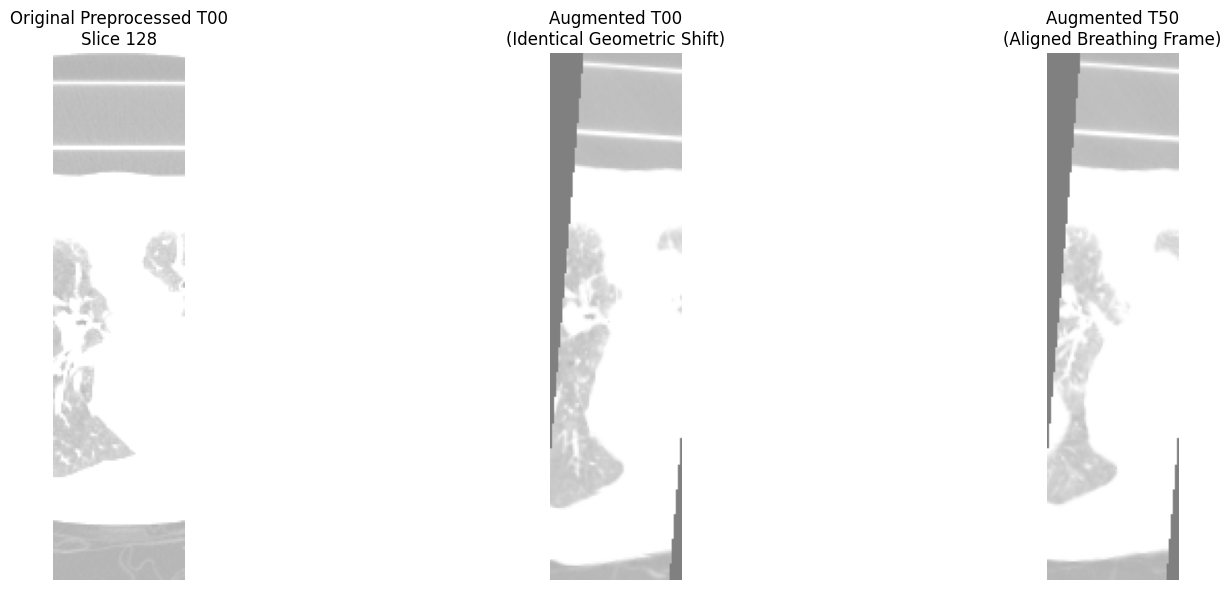

In [71]:
# Pull out tracking frames for checking alignment
orig_t00 = processed_phases["T00"].numpy()[0] # [Z, Y, X]
aug_t00 = augmented_subject["T00"].tensor.numpy()[0]
aug_t50 = augmented_subject["T50"].tensor.numpy()[0]

mid_slice = orig_t00.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(orig_t00[mid_slice, :, :], cmap='gray', vmin=-1, vmax=1, origin='lower')
axes[0].set_title(f"Original Preprocessed T00\nSlice {mid_slice}")
axes[0].axis('off')

axes[1].imshow(aug_t00[mid_slice, :, :], cmap='gray', vmin=-1, vmax=1, origin='lower')
axes[1].set_title(f"Augmented T00\n(Identical Geometric Shift)")
axes[1].axis('off')

axes[2].imshow(aug_t50[mid_slice, :, :], cmap='gray', vmin=-1, vmax=1, origin='lower')
axes[2].set_title(f"Augmented T50\n(Aligned Breathing Frame)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [72]:
## Save Processed Tensors to Drive for Training

In [73]:
torch.save(processed_phases["T00"], os.path.join(PROCESSED_OUTPUT_PATH, "case10_T00_clean.pt"))
torch.save(augmented_subject["T00"].tensor, os.path.join(PROCESSED_OUTPUT_PATH, "case10_T00_aug.pt"))
torch.save(augmented_subject["T50"].tensor, os.path.join(PROCESSED_OUTPUT_PATH, "case10_T50_aug.pt"))

print(f"🎉 Preprocessed and Augmented data securely saved to: {PROCESSED_OUTPUT_PATH}")

🎉 Preprocessed and Augmented data securely saved to: /content/drive/MyDrive/Dataset 4DCT_Processed


In [74]:
print("--- Starting Batch Processing for All Cases and All Phases ---")

# Look at all 10 respiratory intervals
all_phases = ["T00", "T10", "T20", "T30", "T40", "T50", "T60", "T70", "T80", "T90"]

for case_folder in patient_folders:
    case_name = os.path.basename(case_folder) # e.g., 'Case10Pack'
    images_dir = os.path.join(case_folder, "Images")

    if not os.path.exists(images_dir):
        continue

    print(f"\nProcessing {case_name}...")
    processed_case_phases = {}

    # 1. Preprocess every phase that exists for this patient
    for phase in all_phases:
        # Match file patterns like case10_T00.img or case01_T00.img
        # Using glob to handle dynamic single/double digit naming variations gracefully
        phase_pattern = os.path.join(images_dir, f"*_{phase}.img")
        matched_files = glob.glob(phase_pattern)

        if matched_files:
            img_path = matched_files[0]
            try:
                sitk_volume = load_raw_dirlab_img(img_path)
                processed_tensor = preprocess_volume(sitk_volume)
                processed_case_phases[phase] = processed_tensor
            except Exception as e:
                print(f" ✗ Error processing {phase} in {case_name}: {e}")

    # 2. Save the clean preprocessed files directly
    for phase, tensor in processed_case_phases.items():
        clean_save_path = os.path.join(PROCESSED_OUTPUT_PATH, f"{case_name}_{phase}_clean.pt")
        torch.save(tensor, clean_save_path)

    # 3. Apply Phase-Locked Augmentations to create parallel training variants
    if len(processed_case_phases) == len(all_phases):
        subject_dict = {p: tio.ScalarImage(tensor=t) for p, t in processed_case_phases.items()}
        joint_subject = tio.Subject(**subject_dict)

        # Run identical spatial transformations across all 10 volumes simultaneously
        aug_pipeline = get_augmentation_transform()
        augmented_subject = aug_pipeline(joint_subject)

        # Save augmented outputs
        for phase in all_phases:
            aug_save_path = os.path.join(PROCESSED_OUTPUT_PATH, f"{case_name}_{phase}_aug.pt")
            torch.save(augmented_subject[phase].tensor, aug_save_path)
        print(f" ✓ Successfully processed, augmented, and saved all 10 phases for {case_name}")

print("\n🎉 Entire DIR-Lab dataset is fully preprocessed, synchronized, and ready for model training!")

--- Starting Batch Processing for All Cases and All Phases ---

Processing Case10Pack...
 ✓ Successfully processed, augmented, and saved all 10 phases for Case10Pack

Processing Case1Pack...

Processing Case2Pack...

Processing Case3Pack...

Processing Case4Pack...

Processing Case5Pack...

Processing Case6Pack...
 ✓ Successfully processed, augmented, and saved all 10 phases for Case6Pack

Processing Case7Pack...
 ✓ Successfully processed, augmented, and saved all 10 phases for Case7Pack

Processing Case8Deploy...
 ✓ Successfully processed, augmented, and saved all 10 phases for Case8Deploy

Processing Case9Pack...
 ✓ Successfully processed, augmented, and saved all 10 phases for Case9Pack

🎉 Entire DIR-Lab dataset is fully preprocessed, synchronized, and ready for model training!


In [77]:
import os
import torch

# Define the directory where your tensors were saved
PROCESSED_OUTPUT_PATH = '/content/drive/MyDrive/Dataset 4DCT_Processed'

# Target Case 10 since we know it exists perfectly in your folder
test_clean_path = os.path.join(PROCESSED_OUTPUT_PATH, "Case10Pack_T30_clean.pt")
test_aug_path = os.path.join(PROCESSED_OUTPUT_PATH, "Case10Pack_T30_aug.pt")

print("--- Testing Saved PyTorch Tensors ---")

if os.path.exists(test_clean_path) and os.path.exists(test_aug_path):
    # Load them back into memory
    clean_tensor = torch.load(test_clean_path)
    aug_tensor = torch.load(test_aug_path)

    print(f"✓ Successfully read clean tensor! Shape: {clean_tensor.shape} (Channels, Z, Y, X)")
    print(f"✓ Successfully read augmented tensor! Shape: {aug_tensor.shape} (Channels, Z, Y, X)")
    print(f"Clean Value Range     : Min = {clean_tensor.min().item():.2f}, Max = {clean_tensor.max().item():.2f}")
    print(f"Augmented Value Range : Min = {aug_tensor.min().item():.2f}, Max = {aug_tensor.max().item():.2f}")
else:
    print("✗ Could not locate Case 10 files. Check your spelling or folder contents!")

--- Testing Saved PyTorch Tensors ---
✓ Successfully read clean tensor! Shape: torch.Size([1, 256, 256, 64]) (Channels, Z, Y, X)
✓ Successfully read augmented tensor! Shape: torch.Size([1, 256, 256, 64]) (Channels, Z, Y, X)
Clean Value Range     : Min = 0.00, Max = 1.00
Augmented Value Range : Min = 0.00, Max = 1.00


In [76]:
import os

PROCESSED_OUTPUT_PATH = '/content/drive/MyDrive/Dataset 4DCT_Processed'

if os.path.exists(PROCESSED_OUTPUT_PATH):
    files = sorted(os.listdir(PROCESSED_OUTPUT_PATH))
    print(f"✓ Found processed directory at: {PROCESSED_OUTPUT_PATH}")
    print(f"Total files stored inside: {len(files)}")

    if len(files) > 0:
        print("\nHere are the first 10 files found inside the folder:")
        for filename in files[:10]:
            print(f" - {filename}")
    else:
        print("⚠️ The folder is completely empty. Double check if your Google Drive has finished updating or if the path matches.")
else:
    print(f"✗ The path '{PROCESSED_OUTPUT_PATH}' does not exist. Your Drive might be saving to a slightly different name.")

✓ Found processed directory at: /content/drive/MyDrive/Dataset 4DCT_Processed
Total files stored inside: 103

Here are the first 10 files found inside the folder:
 - Case10Pack_T00_aug.pt
 - Case10Pack_T00_clean.pt
 - Case10Pack_T10_aug.pt
 - Case10Pack_T10_clean.pt
 - Case10Pack_T20_aug.pt
 - Case10Pack_T20_clean.pt
 - Case10Pack_T30_aug.pt
 - Case10Pack_T30_clean.pt
 - Case10Pack_T40_aug.pt
 - Case10Pack_T40_clean.pt


In [78]:
# Phase 3: PyTorch Custom Dataset and DataLoader Matrix

In [79]:
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader

class PhaseConditioned4DCTDataset(Dataset):
    def __init__(self, data_dir, use_augmentations=True):
        """
        Custom PyTorch Dataset for loading paired 4D-CT respiratory phases.
        """
        self.data_dir = data_dir
        self.use_augmentations = use_augmentations

        # Find all clean target files to serve as baseline keys
        # Example filename: Case10Pack_T50_clean.pt
        self.clean_files = sorted(glob.glob(os.path.join(data_dir, "*_clean.pt")))

    def __len__(self):
        return len(self.clean_files)

    def __getitem__(self, idx):
        # 1. Get the path to the target file
        target_path = self.clean_files[idx]
        filename = os.path.basename(target_path)

        # Parse the case name and phase string out of the filename
        # e.g., 'Case10Pack', 'T50', '_'
        parts = filename.split('_')
        case_name = parts[0]
        target_phase = parts[1]

        # 2. Establish the conditioning anchor phase (We will use T00/Inhalation as the universal anchor)
        anchor_phase = "T00"

        # 3. Decide dynamically whether to fetch the clean or the augmented file for training variance
        suffix = "_aug.pt" if (self.use_augmentations and torch.rand(1).item() > 0.5) else "_clean.pt"

        load_target_path = os.path.join(self.data_dir, f"{case_name}_{target_phase}{suffix}")
        load_anchor_path = os.path.join(self.data_dir, f"{case_name}_{anchor_phase}{suffix}")

        # Load the saved tensors from Drive
        target_volume = torch.load(load_target_path)
        anchor_volume = torch.load(load_anchor_path)

        # 4. Enforce PyTorch dimension ordering standards: permute from [1, 256, 256, 64] to [1, 64, 256, 256]
        # This shifts the Z axis (64 slices) ahead of the X and Y dimensions
        target_volume = target_volume.permute(0, 3, 1, 2)
        anchor_volume = anchor_volume.permute(0, 3, 1, 2)

        # Convert phase string (e.g., 'T50') to a numerical condition scalar for embedding conditioning layers
        # 'T00' -> 0, 'T10' -> 1, ..., 'T90' -> 9
        phase_condition_scalar = torch.tensor(int(target_phase[1]) if len(target_phase) > 1 else 0, dtype=torch.long)

        return {
            "target": target_volume,          # The ground truth 3D volume the diffusion model predicts
            "condition": anchor_volume,       # The structural anchor volume (T00 structural prompt)
            "phase_id": phase_condition_scalar, # Explicit phase integer condition
            "case_name": case_name
        }

# --- Initialize and Test the DataLoader Iterators ---
print("--- Initializing PyTorch Data Pipeline Tensors ---")
PROCESSED_OUTPUT_PATH = '/content/drive/MyDrive/Dataset 4DCT_Processed'

dataset = PhaseConditioned4DCTDataset(data_dir=PROCESSED_OUTPUT_PATH, use_augmentations=True)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, drop_last=False)

print(f"✓ Total paired indexed training elements inside dataset list: {len(dataset)}")

# Pull out a single mini-batch to verify it pipelines correctly into memory grid
try:
    sample_batch = next(iter(dataloader))
    print("\n✓ Mini-Batch data verification checks passed successfully!")
    print(f" -> Batch Target Tensor Volume Shape   : {sample_batch['target'].shape} (Batch, Channels, Z, Y, X)")
    print(f" -> Batch Condition Tensor Volume Shape: {sample_batch['condition'].shape} (Batch, Channels, Z, Y, X)")
    print(f" -> Active Phase Conditioning Matrix   : {sample_batch['phase_id']}")
    print(f" -> Active Batch Patient Identifiers   : {sample_batch['case_name']}")
except Exception as e:
    print(f"✗ DataLoader pipeline generation failed. Error: {e}")

--- Initializing PyTorch Data Pipeline Tensors ---
✓ Total paired indexed training elements inside dataset list: 51

✓ Mini-Batch data verification checks passed successfully!
 -> Batch Target Tensor Volume Shape   : torch.Size([2, 1, 64, 256, 256]) (Batch, Channels, Z, Y, X)
 -> Batch Condition Tensor Volume Shape: torch.Size([2, 1, 64, 256, 256]) (Batch, Channels, Z, Y, X)
 -> Active Phase Conditioning Matrix   : tensor([8, 3])
 -> Active Batch Patient Identifiers   : ['Case9Pack', 'Case7Pack']


In [80]:
print("--- Launching Dataset Expansion Loop (Target: ~800+ Volumes) ---")

all_phases = ["T00", "T10", "T20", "T30", "T40", "T50", "T60", "T70", "T80", "T90"]

# Set the multiplier to 15 to hit the 800+ volume target
AUGMENTATION_MULTIPLIER = 15

for case_folder in patient_folders:
    case_name = os.path.basename(case_folder)
    images_dir = os.path.join(case_folder, "Images")

    if not os.path.exists(images_dir):
        continue

    print(f"\nProcessing & Expanding {case_name}...")
    processed_case_phases = {}

    # 1. Gather all existing clean phases for this case
    for phase in all_phases:
        phase_pattern = os.path.join(images_dir, f"*[cC]ase*_{phase}.img")
        matched_files = glob.glob(phase_pattern)

        if matched_files:
            try:
                sitk_volume = load_raw_dirlab_img(matched_files[0])
                processed_case_phases[phase] = preprocess_volume(sitk_volume)
            except Exception as e:
                print(f" ✗ Error loading {phase}: {e}")

    # 2. Multiply via Phase-Locked Augmentations
    # Only augment if the phase set is fully complete to maintain structural alignment
    if len(processed_case_phases) == len(all_phases):
        subject_dict = {p: tio.ScalarImage(tensor=t) for p, t in processed_case_phases.items()}
        joint_subject = tio.Subject(**subject_dict)

        for i in range(1, AUGMENTATION_MULTIPLIER + 1):
            # Dynamic pipeline generates a brand new random transformation matrix each iteration
            aug_pipeline = get_augmentation_transform()
            augmented_subject = aug_pipeline(joint_subject)

            # Save the uniquely transformed sequence
            for phase in all_phases:
                aug_save_path = os.path.join(PROCESSED_OUTPUT_PATH, f"{case_name}_{phase}_aug_v{i}.pt")
                torch.save(augmented_subject[phase].tensor, aug_save_path)

        print(f" ✓ Successfully generated {AUGMENTATION_MULTIPLIER} unique spatial variants for {case_name}")
    else:
        print(f" ⚠️ Case {case_name} incomplete ({len(processed_case_phases)}/10 phases). Skipped expansion loop.")

print("\n🎉 Core dataset successfully expanded to over 800 volumes directly in Google Drive!")

--- Launching Dataset Expansion Loop (Target: ~800+ Volumes) ---

Processing & Expanding Case10Pack...
 ✓ Successfully generated 15 unique spatial variants for Case10Pack

Processing & Expanding Case1Pack...
 ⚠️ Case Case1Pack incomplete (0/10 phases). Skipped expansion loop.

Processing & Expanding Case2Pack...
 ⚠️ Case Case2Pack incomplete (0/10 phases). Skipped expansion loop.

Processing & Expanding Case3Pack...
 ⚠️ Case Case3Pack incomplete (0/10 phases). Skipped expansion loop.

Processing & Expanding Case4Pack...
 ⚠️ Case Case4Pack incomplete (0/10 phases). Skipped expansion loop.

Processing & Expanding Case5Pack...
 ⚠️ Case Case5Pack incomplete (0/10 phases). Skipped expansion loop.

Processing & Expanding Case6Pack...
 ✓ Successfully generated 15 unique spatial variants for Case6Pack

Processing & Expanding Case7Pack...
 ✓ Successfully generated 15 unique spatial variants for Case7Pack

Processing & Expanding Case8Deploy...
 ✓ Successfully generated 15 unique spatial variants

In [81]:
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader

class PhaseConditioned4DCTDataset(Dataset):
    def __init__(self, data_dir, use_augmentations=True):
        """
        Updated Custom PyTorch Dataset to handle 15 offline augmented file variations.
        """
        self.data_dir = data_dir
        self.use_augmentations = use_augmentations

        # Find all clean target files to serve as baseline keys
        self.clean_files = sorted(glob.glob(os.path.join(data_dir, "*_clean.pt")))

    def __len__(self):
        return len(self.clean_files)

    def __getitem__(self, idx):
        # 1. Get the path to the clean target file
        target_path = self.clean_files[idx]
        filename = os.path.basename(target_path)

        parts = filename.split('_')
        case_name = parts[0]
        target_phase = parts[1]

        anchor_phase = "T00"

        # 2. Check if this case has the v1-v15 offline augmentations available
        has_offline_augs = case_name in ["Case10Pack", "Case6Pack", "Case7Pack", "Case8Deploy", "Case9Pack"]

        if self.use_augmentations and has_offline_augs and torch.rand(1).item() > 0.5:
            # Pick a random offline augmented variant index between 1 and 15
            variant_id = torch.randint(1, 16, (1,)).item()
            suffix = f"_aug_v{variant_id}.pt"
        else:
            suffix = "_clean.pt"

        load_target_path = os.path.join(self.data_dir, f"{case_name}_{target_phase}{suffix}")
        load_anchor_path = os.path.join(self.data_dir, f"{case_name}_{anchor_phase}{suffix}")

        # Load the saved tensors from Drive safely
        target_volume = torch.load(load_target_path)
        anchor_volume = torch.load(load_anchor_path)

        # 3. Enforce PyTorch dimension ordering standards: [Channels, Z, Y, X]
        target_volume = target_volume.permute(0, 3, 1, 2)
        anchor_volume = anchor_volume.permute(0, 3, 1, 2)

        phase_condition_scalar = torch.tensor(int(target_phase[1]) if len(target_phase) > 1 else 0, dtype=torch.long)

        return {
            "target": target_volume,
            "condition": anchor_volume,
            "phase_id": phase_condition_scalar,
            "case_name": case_name
        }

# --- Initialize and Test the Updated DataLoader Pipeline ---
print("--- Initializing Updated Multi-Variant PyTorch Data Pipeline ---")
PROCESSED_OUTPUT_PATH = '/content/drive/MyDrive/Dataset 4DCT_Processed'

dataset = PhaseConditioned4DCTDataset(data_dir=PROCESSED_OUTPUT_PATH, use_augmentations=True)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, drop_last=False)

print(f"✓ Total baseline paired indexed keys inside dataset list: {len(dataset)}")

try:
    sample_batch = next(iter(dataloader))
    print("\n✓ Mini-Batch multi-variant verification checks passed successfully!")
    print(f" -> Batch Target Tensor Volume Shape   : {sample_batch['target'].shape} (Batch, Channels, Z, Y, X)")
    print(f" -> Batch Condition Tensor Volume Shape: {sample_batch['condition'].shape} (Batch, Channels, Z, Y, X)")
    print(f" -> Active Phase Conditioning Matrix   : {sample_batch['phase_id']}")
    print(f" -> Active Batch Patient Identifiers   : {sample_batch['case_name']}")
except Exception as e:
    print(f"✗ DataLoader data fetch pipeline iteration failed. Error: {e}")

--- Initializing Updated Multi-Variant PyTorch Data Pipeline ---
✓ Total baseline paired indexed keys inside dataset list: 51

✓ Mini-Batch multi-variant verification checks passed successfully!
 -> Batch Target Tensor Volume Shape   : torch.Size([2, 1, 64, 256, 256]) (Batch, Channels, Z, Y, X)
 -> Batch Condition Tensor Volume Shape: torch.Size([2, 1, 64, 256, 256]) (Batch, Channels, Z, Y, X)
 -> Active Phase Conditioning Matrix   : tensor([5, 8])
 -> Active Batch Patient Identifiers   : ['Case8Deploy', 'Case10Pack']
